# Exploratory analysis: traffic, conversion, funnel and products

Charts for the main questions, built on the PostgreSQL view `v_sessions_enriched`
(one row per session) and the order tables. Monthly charts use full months only (April 2012 to February 2015).
Every chart is saved to `images/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent / "src"))
from chart_style import (CHANNEL_COLORS, DEVICE_COLORS, FUNNEL_BLUE, HIGHLIGHT, PRODUCT_COLORS, TEXT_MUTED,
                         apply_style)
from db import get_engine

apply_style()
engine = get_engine()
IMAGES = Path.cwd().parent / "images"
pd.set_option("display.float_format", "{:,.4f}".format)


def sql(query):
    return pd.read_sql(query, engine)


def pct_axis(ax, axis="y", decimals=0):
    fmt = plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

## 1. Channel mix over time

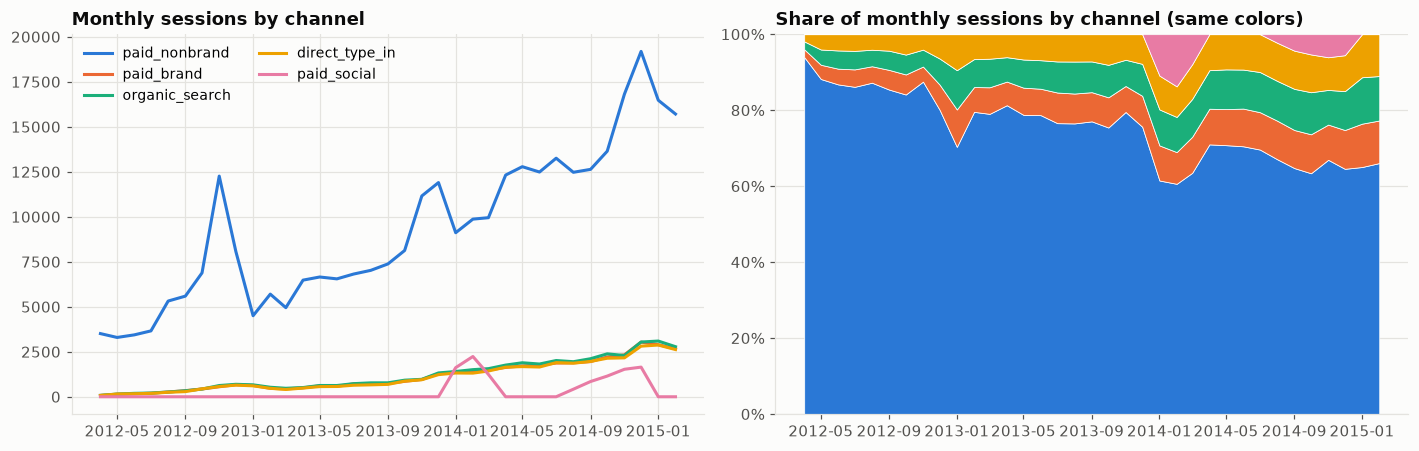

channel_group,paid_nonbrand,paid_brand,organic_search,direct_type_in,paid_social
Apr12-Feb13,0.8448,0.0512,0.0540,0.0500,0.0000
Apr13-Feb14,0.7504,0.0762,0.0801,0.0727,0.0205
Apr14-Feb15,0.6693,0.1006,0.1059,0.0980,0.0262


In [2]:
monthly = sql("""
    SELECT session_month, channel_group, COUNT(*) AS sessions, SUM(has_order) AS orders
    FROM v_sessions_enriched
    WHERE session_month BETWEEN '2012-04-01' AND '2015-02-01'
    GROUP BY 1, 2
""")
monthly["session_month"] = pd.to_datetime(monthly["session_month"])
sessions_wide = monthly.pivot(index="session_month", columns="channel_group", values="sessions").fillna(0)
channel_order = ["paid_nonbrand", "paid_brand", "organic_search", "direct_type_in", "paid_social"]
sessions_wide = sessions_wide[channel_order]
share = sessions_wide.div(sessions_wide.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ch in channel_order:
    axes[0].plot(sessions_wide.index, sessions_wide[ch], color=CHANNEL_COLORS[ch], label=ch)
axes[0].set_title("Monthly sessions by channel")
axes[0].legend(ncol=2, fontsize=9)
axes[1].stackplot(share.index, [share[ch] for ch in channel_order],
                  colors=[CHANNEL_COLORS[ch] for ch in channel_order], labels=channel_order,
                  edgecolor="white", linewidth=0.5)
axes[1].set_title("Share of monthly sessions by channel (same colors)")
axes[1].set_ylim(0, 1)
pct_axis(axes[1])
fig.tight_layout()
fig.savefig(IMAGES / "channel_mix.png")
plt.show()

year_share = share.groupby(np.select(
    [share.index < "2013-03-01", share.index < "2014-03-01"], ["Apr12-Feb13", "Apr13-Feb14"], "Apr14-Feb15"
)).mean()
year_share

**Observations**

- Paid nonbrand search drives the business but its share keeps falling: about 84% of sessions in Apr12-Feb13,
  75% in Apr13-Feb14 and 67% in Apr14-Feb15.
- Paid brand, organic search and direct type-in roughly doubled their share, from about 5% to about 10% each.
  These visitors already know the brand and cost little or nothing, so the business depends less on nonbrand bids.
- Paid nonbrand peaked in November 2012 and fell by a third in December 2012 (8,066 sessions). It dropped again to
  about 4,500 in January 2013, which looks like a bid cut or the end of a holiday push; the data does not say which.
- Paid social ran in two bursts, January to March 2014 (pilot) and August to December 2014 (desktop_targeted),
  peaking at about 2,200 sessions a month.

## 2. Conversion rate by channel and device

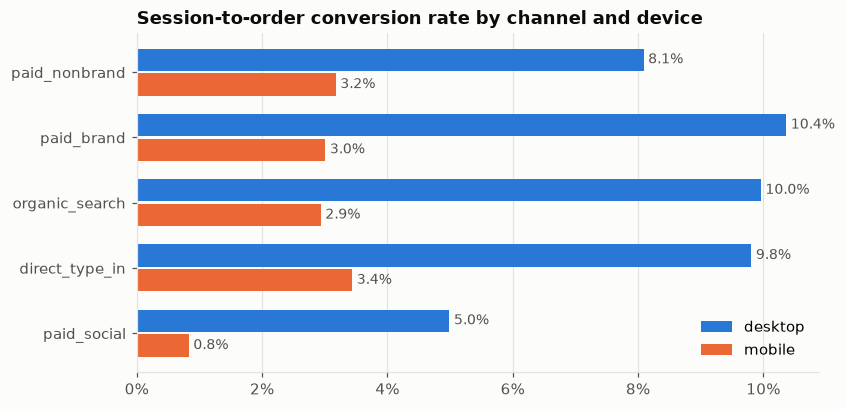

sessions             conv_rate        revenue_per_session  \
device_type         desktop      mobile   desktop mobile             desktop   
channel_group                                                                  
direct_type_in  23,284.0000 16,633.0000    0.0981 0.0344              6.0170   
organic_search  28,292.0000 15,119.0000    0.0996 0.0294              6.0118   
paid_brand      26,789.0000 14,454.0000    0.1037 0.0301              6.2879   
paid_nonbrand  242,550.0000 95,065.0000    0.0809 0.0318              4.8132   
paid_social      6,112.0000  4,573.0000    0.0499 0.0083              3.2189   

                       
device_type    mobile  
channel_group          
direct_type_in 2.0757  
organic_search 1.7675  
paid_brand     1.8260  
paid_nonbrand  1.9200  
paid_social    0.5654

In [3]:
cd = sql("""
    SELECT channel_group, device_type, COUNT(*) AS sessions, SUM(has_order) AS orders,
           SUM(revenue_usd)::FLOAT AS revenue
    FROM v_sessions_enriched
    GROUP BY 1, 2
""")
cd["conv_rate"] = cd["orders"] / cd["sessions"]
cd["revenue_per_session"] = cd["revenue"] / cd["sessions"]

conv = cd.pivot(index="channel_group", columns="device_type", values="conv_rate").loc[channel_order[::-1]]
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(conv))
h = 0.38
for i, dev in enumerate(["desktop", "mobile"]):
    bars = ax.barh(y + (0.5 - i) * h, conv[dev], height=h - 0.04, color=DEVICE_COLORS[dev], label=dev)
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in conv[dev]], padding=3, fontsize=9, color=TEXT_MUTED)
ax.set_yticks(y)
ax.set_yticklabels(conv.index)
pct_axis(ax, "x")
ax.set_title("Session-to-order conversion rate by channel and device")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
fig.savefig(IMAGES / "conversion_by_channel_device.png")
plt.show()

cd.pivot(index="channel_group", columns="device_type", values=["sessions", "conv_rate", "revenue_per_session"])

**Observations**

- Desktop converts far better than mobile in every channel: paid brand 10.4% vs 3.0%, organic 10.0% vs 2.9%,
  direct 9.8% vs 3.4%, paid nonbrand 8.1% vs 3.2%, paid social 5.0% vs 0.8%.
- Overall, desktop is 8.50% vs 3.09% for mobile, and revenue per session is $5.09 vs $1.87. Mobile is 31% of sessions
  but only 14% of revenue.
- On desktop, visitors who already know the brand (paid brand, organic, direct: 9.8-10.4%) convert better than
  paid nonbrand (8.1%).
- Paid social is the weakest channel: 3.21% conversion and $2.08 revenue per session overall, and only 0.8% on mobile.

## 3. Conversion funnel

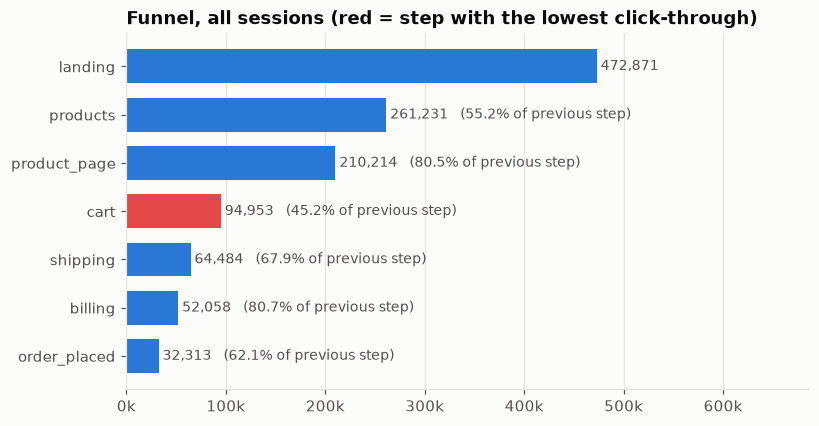

device_type,step_ctr_all,step_ctr_desktop,step_ctr_mobile
landing,NaN,NaN,NaN
products,0.5524,0.5881,0.4725
product_page,0.8047,0.8486,0.6821
cart,0.4517,0.4605,0.4212
shipping,0.6791,0.7011,0.5956
billing,0.8073,0.8298,0.7069
order_placed,0.6207,0.6359,0.5408


In [4]:
funnel = sql("""
    SELECT device_type,
           COUNT(*) AS landing, SUM(saw_products) AS products, SUM(saw_product_page) AS product_page,
           SUM(saw_cart) AS cart, SUM(saw_shipping) AS shipping, SUM(saw_billing) AS billing,
           SUM(saw_thank_you) AS order_placed
    FROM v_sessions_enriched
    GROUP BY 1
""").set_index("device_type").T
funnel["all"] = funnel.sum(axis=1)
funnel["step_ctr_all"] = funnel["all"] / funnel["all"].shift(1)
funnel["step_ctr_desktop"] = funnel["desktop"] / funnel["desktop"].shift(1)
funnel["step_ctr_mobile"] = funnel["mobile"] / funnel["mobile"].shift(1)

steps = funnel.index.tolist()
biggest_drop = funnel["step_ctr_all"].idxmin()
fig, ax = plt.subplots(figsize=(8, 4.2))
y = np.arange(len(steps))[::-1]
colors = [HIGHLIGHT if s == biggest_drop else FUNNEL_BLUE for s in steps]
bars = ax.barh(y, funnel["all"], color=colors, height=0.7)
for yi, s in zip(y, steps):
    total = funnel.loc[s, "all"]
    ctr = funnel.loc[s, "step_ctr_all"]
    label = f"{total:,.0f}" + ("" if pd.isna(ctr) else f"   ({ctr:.1%} of previous step)")
    ax.text(total + 4000, yi, label, va="center", fontsize=9, color=TEXT_MUTED)
ax.set_yticks(y)
ax.set_yticklabels(steps)
ax.set_xlim(0, funnel["all"].max() * 1.45)
ax.set_title("Funnel, all sessions (red = step with the lowest click-through)")
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1000:,.0f}k"))
fig.savefig(IMAGES / "funnel.png")
plt.show()

funnel[["step_ctr_all", "step_ctr_desktop", "step_ctr_mobile"]]

**Observations**

- 472,871 sessions became 32,313 orders: 6.83% overall.
- The biggest leak is **product page to cart**: only 45.2% of product page viewers add to cart. The next is
  landing to products (55.2%), which is mostly bounces.
- Billing to order (62.1%) is the third weakest step, even after /billing-2 improved it.
- Mobile is weaker at every step. The largest gaps vs desktop are products to product page (68% vs 85%),
  shipping to billing (71% vs 83%), landing to products (47% vs 59%) and cart to shipping (60% vs 70%).
  Mobile checkout is a clear opportunity.

## 4. Bounce rate and conversion by landing page

Landing pages served different traffic in different periods, so this is descriptive. The fair page-vs-page
comparisons are the A/B tests in `02_ab_tests.ipynb`.

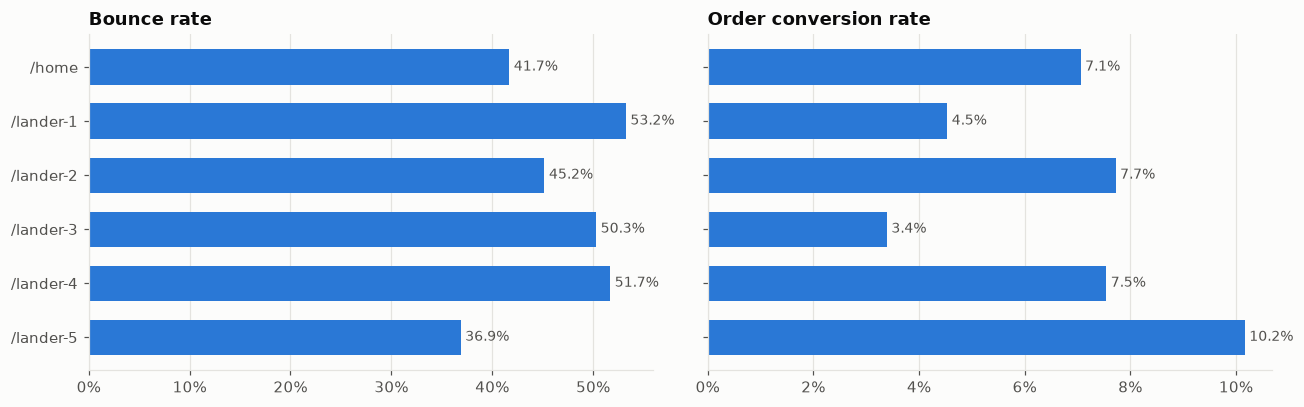

,sessions,bounce_rate,conv_rate,revenue_per_session,first_seen,last_seen
landing_page,,,,,,
/home,137576,0.4168,0.0706,4.2545,2012-03-19,2015-03-19
/lander-1,47574,0.5324,0.0453,2.2859,2012-06-19,2013-03-10
/lander-2,131170,0.4517,0.0772,4.5343,2013-01-14,2014-12-27
/lander-3,79000,0.5029,0.0339,2.0972,2013-07-09,2015-03-19
/lander-4,9385,0.5169,0.0754,4.8440,2014-02-02,2014-04-19
/lander-5,68166,0.3687,0.1017,6.4335,2014-08-02,2015-03-19


In [5]:
lp = sql("""
    SELECT landing_page, COUNT(*) AS sessions, AVG(is_bounce)::FLOAT AS bounce_rate,
           AVG(has_order)::FLOAT AS conv_rate, AVG(revenue_usd)::FLOAT AS revenue_per_session,
           MIN(session_date) AS first_seen, MAX(session_date) AS last_seen
    FROM v_sessions_enriched
    GROUP BY 1
    ORDER BY 1
""").set_index("landing_page")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
y = np.arange(len(lp))[::-1]
for ax, col, title in [(axes[0], "bounce_rate", "Bounce rate"), (axes[1], "conv_rate", "Order conversion rate")]:
    bars = ax.barh(y, lp[col], color=FUNNEL_BLUE, height=0.65)
    ax.bar_label(bars, labels=[f"{v:.1%}" for v in lp[col]], padding=3, fontsize=9, color=TEXT_MUTED)
    ax.set_title(title)
    pct_axis(ax, "x")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(y)
axes[0].set_yticklabels(lp.index)
fig.tight_layout()
fig.savefig(IMAGES / "landing_pages.png")
plt.show()
lp

**Observations**

- /lander-5 has the lowest bounce rate (36.9%), the highest conversion (10.2%) and the highest revenue per session ($6.43).
- /home looks strong (41.7% bounce, 7.1% conversion) mainly because it receives brand, organic and direct visitors.
- /lander-3 (50.3% bounce, 3.4% conversion) only serves mobile traffic, which converts less on every page.
- These raw numbers mix page quality with traffic mix and time period; the A/B notebook has the fair comparisons.

## 5. Product revenue trend

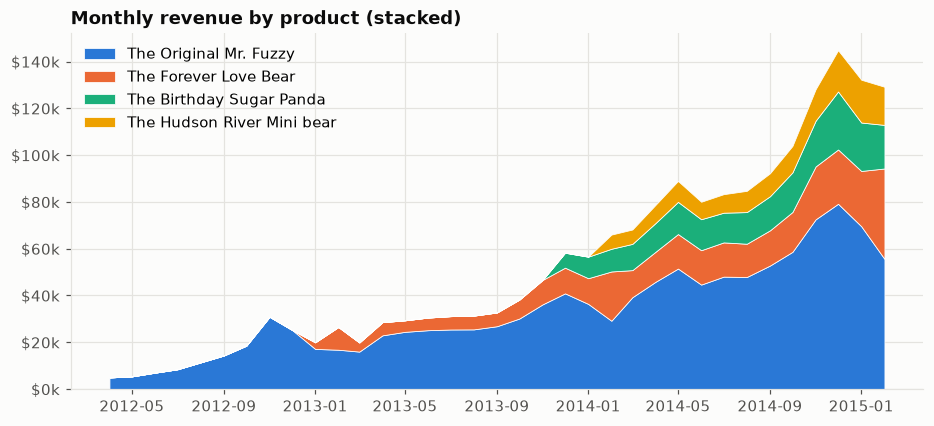

,revenue,margin,items,margin_pct,revenue_share
product_name,,,,,
The Birthday Sugar Panda,"217,164.7800","148,743.0000",4722,0.6849,0.1170
The Forever Love Bear,"334,324.2700","208,987.5000",5573,0.6251,0.1801
The Hudson River Mini bear,"140,203.2500","95,837.5000",4675,0.6836,0.0755
The Original Mr. Fuzzy,"1,164,866.9800","710,711.0000",23302,0.6101,0.6274


product_name,The Original Mr. Fuzzy,The Forever Love Bear,The Birthday Sugar Panda,The Hudson River Mini bear
month,,,,
2014-02-01,"29,194.1600","21,056.4900","9,703.8900","6,057.9800"
2015-02-01,"55,638.8700","38,633.5600","18,625.9500","16,314.5600"


In [6]:
prod = sql("""
    SELECT DATE_TRUNC('month', i.created_at)::DATE AS month, p.product_name,
           SUM(i.price_usd)::FLOAT AS revenue, SUM(i.price_usd - i.cogs_usd)::FLOAT AS margin, COUNT(*) AS items
    FROM order_items i
    JOIN products p ON p.product_id = i.product_id
    WHERE i.created_at >= '2012-04-01' AND i.created_at < '2015-03-01'
    GROUP BY 1, 2
""")
prod["month"] = pd.to_datetime(prod["month"])
rev = prod.pivot(index="month", columns="product_name", values="revenue").fillna(0)[list(PRODUCT_COLORS)]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.stackplot(rev.index, [rev[p] for p in rev.columns], colors=[PRODUCT_COLORS[p] for p in rev.columns],
             labels=rev.columns, edgecolor="white", linewidth=0.5)
ax.set_title("Monthly revenue by product (stacked)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v / 1000:,.0f}k"))
ax.legend(loc="upper left")
fig.savefig(IMAGES / "product_revenue.png")
plt.show()

totals = prod.groupby("product_name")[["revenue", "margin", "items"]].sum()
totals["margin_pct"] = totals["margin"] / totals["revenue"]
totals["revenue_share"] = totals["revenue"] / totals["revenue"].sum()
display(totals)
rev.loc[["2014-02-01", "2015-02-01"]]

**Observations**

- The Original Mr. Fuzzy is 63% of revenue (April 2012 to February 2015), but newer products are growing faster.
  From February 2014 to February 2015, Mr. Fuzzy revenue went from $29.2k to $55.6k, while the Mini Bear went
  from $6.1k to $16.3k.
- Newer products have better margins: Sugar Panda and Mini Bear 68%, Love Bear 63%, Mr. Fuzzy 61%.
- The Love Bear visibly jumps in February 2013 and February 2014 (Valentine's Day), and total revenue peaks around
  November and December each year (holiday season).

## 6. Refund rate by product

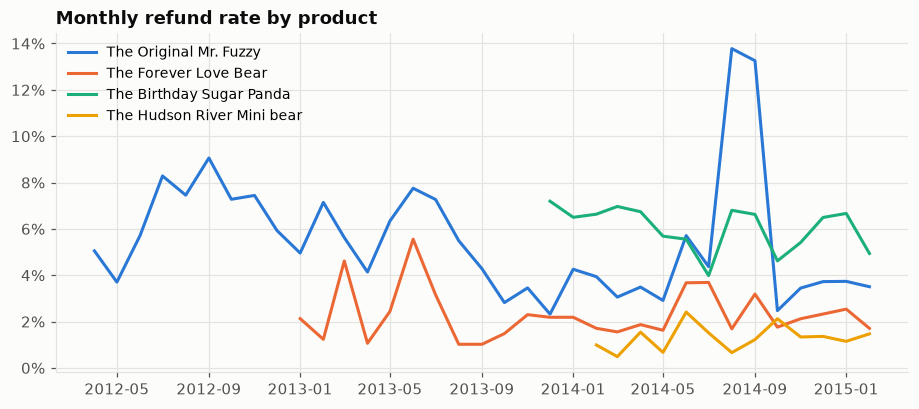

month
2014-08-01   0.1378
2014-09-01   0.1326
2012-09-01   0.0906
2012-07-01   0.0828
2013-06-01   0.0775
Name: The Original Mr. Fuzzy, dtype: float64

In [7]:
ref = sql("""
    SELECT DATE_TRUNC('month', i.created_at)::DATE AS month, p.product_name,
           COUNT(*) AS items, COUNT(r.order_item_refund_id) AS refunded
    FROM order_items i
    JOIN products p ON p.product_id = i.product_id
    LEFT JOIN order_item_refunds r ON r.order_item_id = i.order_item_id
    WHERE i.created_at >= '2012-04-01' AND i.created_at < '2015-03-01'
    GROUP BY 1, 2
""")
ref["month"] = pd.to_datetime(ref["month"])
ref["refund_rate"] = ref["refunded"] / ref["items"]
rate = ref.pivot(index="month", columns="product_name", values="refund_rate")[list(PRODUCT_COLORS)]

fig, ax = plt.subplots(figsize=(10, 4))
for p in rate.columns:
    ax.plot(rate.index, rate[p], color=PRODUCT_COLORS[p], label=p)
ax.set_title("Monthly refund rate by product")
pct_axis(ax)
ax.legend(loc="upper left", fontsize=9)
fig.savefig(IMAGES / "refund_rate.png")
plt.show()

mr = rate["The Original Mr. Fuzzy"]
mr.sort_values(ascending=False).head(5)

**Observations**

- Mr. Fuzzy's refund rate spiked to 13.8% in August 2014 and 13.3% in September 2014, against 5.1% for the product
  overall, then fell to 2.5% in October 2014. That pattern fits a supplier quality problem that was fixed.
- Mr. Fuzzy also ran at 7-9% in mid-2012 (8.3% in July, 9.1% in September) and settled around 3-4% from late 2013.
- The Birthday Sugar Panda has the highest overall refund rate (6.04%) and should be watched; the Mini Bear
  has the lowest (1.28%).

## 7. Is traffic getting more valuable? Revenue per session by quarter

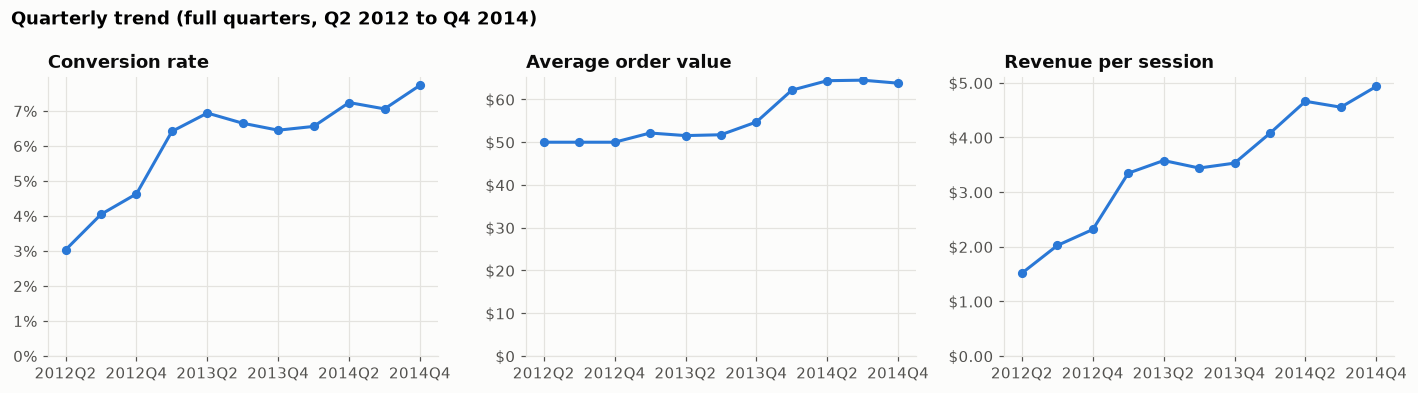

,quarter,sessions,conv_rate,aov,revenue_per_session,label
0,2012-04-01,11433,0.0304,49.9900,1.5172,2012Q2
1,2012-07-01,16892,0.0405,49.9900,2.0242,2012Q3
2,2012-10-01,32266,0.0463,49.9900,2.3162,2012Q4
3,2013-01-01,19833,0.0642,52.1424,3.3468,2013Q1
4,2013-04-01,24745,0.0694,51.5383,3.5782,2013Q2
5,2013-07-01,27663,0.0665,51.7345,3.4411,2013Q3
6,2013-10-01,40540,0.0645,54.7157,3.5307,2013Q4
7,2014-01-01,46779,0.0656,62.1607,4.0781,2014Q1
8,2014-04-01,53129,0.0724,64.3742,4.6625,2014Q2
9,2014-07-01,57141,0.0706,64.4949,4.5543,2014Q3


In [8]:
q = sql("""
    SELECT DATE_TRUNC('quarter', created_at)::DATE AS quarter, COUNT(*) AS sessions,
           AVG(has_order)::FLOAT AS conv_rate,
           (SUM(revenue_usd) / NULLIF(SUM(has_order), 0))::FLOAT AS aov,
           AVG(revenue_usd)::FLOAT AS revenue_per_session
    FROM v_sessions_enriched
    WHERE created_at >= '2012-04-01' AND created_at < '2015-01-01'
    GROUP BY 1
    ORDER BY 1
""")
q["label"] = pd.to_datetime(q["quarter"]).dt.to_period("Q").astype(str)
x = np.arange(len(q))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col, title, fmt in [
    (axes[0], "conv_rate", "Conversion rate", lambda v, _: f"{v:.0%}"),
    (axes[1], "aov", "Average order value", lambda v, _: f"${v:,.0f}"),
    (axes[2], "revenue_per_session", "Revenue per session", lambda v, _: f"${v:,.2f}"),
]:
    ax.plot(x, q[col], color=FUNNEL_BLUE, marker="o", markersize=5)
    ax.set_xticks(x[::2])
    ax.set_xticklabels(q["label"][::2])
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt))
    ax.set_ylim(bottom=0)
fig.suptitle("Quarterly trend (full quarters, Q2 2012 to Q4 2014)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(IMAGES / "revenue_per_session.png")
plt.show()
q

**Observations**

- Revenue per session more than tripled, from $1.52 in Q2 2012 to $4.93 in Q4 2014, so traffic is getting more
  valuable and the business can afford higher paid-search bids.
- Two step changes stand out. In Q1 2013, conversion rose from 4.63% to 6.42% (after the lander and billing tests
  and the Love Bear launch). In Q1 2014, AOV rose from $54.72 to $62.16 (after the cart cross-sell from
  September 2013 and the Sugar Panda and Mini Bear launches).
- Conversion went from 3.04% to 7.74%, and AOV from $49.99 (one product, one item) to about $64.